# Territorial Gain Verification — Event Study

**Goal:** For each ACLED territorial gain event, check whether Wikipedia independently confirms the same actor controls that cell 1–3 months later.

**Design:**
1. Extract ACLED `is_control_signal` events → identify the gaining actor and side
2. Stability filter — does another control signal appear in the same cell the *next* month? (reversal check)
3. Look up Wikipedia `control_status` at M+1, M+2, M+3 for the same cell
4. Score agreement: 1.0 = full match, 0.5 = Wikipedia says `contested` (partial), 0.0 = mismatch
5. Lag curve — what % of ACLED gains does Wikipedia confirm by each lag?

**Data:**
- `checkpoints/myanmar_acled_grouped.parquet` — ACLED with actor taxonomy (from notebook 00)
- `../data/processed/myanmar_priogrid_labels.csv` — Wikipedia cell labels (step 9 output)

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.graph_objects as go
from pathlib import Path

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)

ACLED_PATH = Path('checkpoints/myanmar_acled_grouped.parquet')
WIKI_CELL  = Path('../data/processed/myanmar_priogrid_labels.csv')
FIG_DIR    = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

WIKI_COLOURS = {
    'government':         '#CC3333',
    'resistance':         '#33AA44',
    'ethnic_armed_group': '#2266CC',
    'contested':          '#FF9900',
}

def latlon_to_priogrid_gid(lat, lon):
    row = int((lat + 90) / 0.5) + 1
    col = int((lon + 180) / 0.5) + 1
    return (row - 1) * 720 + col

print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
acled_raw = pd.read_parquet(ACLED_PATH)
acled_raw['event_date'] = pd.to_datetime(acled_raw['event_date'])

WIKI_START = pd.Timestamp('2023-11-01')
WIKI_END   = pd.Timestamp('2026-03-31')

acled = acled_raw[
    (acled_raw['event_date'] >= WIKI_START) &
    (acled_raw['event_date'] <= WIKI_END)
].copy()

acled['priogrid_gid'] = acled.apply(
    lambda r: latlon_to_priogrid_gid(r['latitude'], r['longitude']), axis=1
)
acled['year_month'] = acled['event_date'].dt.to_period('M').astype(str)

wiki = pd.read_csv(WIKI_CELL)

print(f'ACLED (overlap window): {len(acled):,} events')
print(f'Wikipedia cell labels:  {len(wiki):,} cell-months  |  {wiki["priogrid_gid"].nunique()} cells')

ACLED (overlap window): 39,348 events
Wikipedia cell labels:  5,238 cell-months  |  185 cells


## 3. Inspect Control Signal Events

Before defining who gained territory, look at what actors and sub-event types appear in the data.

In [3]:
ctrl_df = acled[acled['is_control_signal']].copy()

print(f'Total control signal events in overlap window: {len(ctrl_df):,}')
print()
print('Sub-event type breakdown:')
print(ctrl_df['sub_event_type'].value_counts().to_string())
print()
print('Side breakdown:')
print(ctrl_df['side'].value_counts().to_string())
print()
print('Actor_group breakdown (top 20):')
print(ctrl_df['actor_group'].value_counts().head(20).to_string())

Total control signal events in overlap window: 441

Sub-event type breakdown:
sub_event_type
Non-state actor overtakes territory    327
Non-violent transfer of territory       75
Government regains territory            37
Headquarters or base established         2

Side breakdown:
side
Anti-junta                     371
Pro-junta                       60
Other / Unmapped                 7
Neutral / Self-administered      3

Actor_group breakdown (top 20):
actor_group
Arakan Army (AA)                           111
Kachin Independence Army (KIA)             102
Tatmadaw                                    59
People's Defence Force                      36
Karen National Liberation Army (KNLA)       34
TNLA                                        30
MNDAA                                       20
Chin Brotherhood Alliance                   10
Chinland Council                             9
Karenni Army                                 6
Three Brotherhood Alliance (collective)      6
Unmapped   

## 4. Step 1 — Identify the Gaining Actor

For every control signal event, `actor1` (and `side`) in ACLED represents the actor doing the gaining:
- `Non-state actor overtakes territory` → the non-state actor (actor1) gains
- `Government regains territory` → government (actor1) gains
- `Non-violent transfer of territory` → actor1 receives/establishes control
- `Headquarters or base established` → actor1 establishes presence

We map gainer to expected Wikipedia label using:
- Pro-junta → `government`
- Anti-junta + EAO keywords → `ethnic_armed_group`
- Anti-junta + PDF/NUG → `resistance`
- Neutral / Self-administered → `ethnic_armed_group`

In [4]:
# Named EAOs (ethnic armed organisations) → expect ethnic_armed_group label
# PDF / NUG forces → expect resistance label
EAO_KEYWORDS = [
    'Arakan Army', 'Kachin Independence', 'Karen National Liberation',
    'Karenni', 'Chin National', 'Chinland', 'Shan State Army', 'RCSS',
    'Pa-O National', 'Mon National', 'Lahu', 'Wa National',
    'TNLA', 'MNDAA', 'KNLA', 'KIA', 'CNF', 'KNDF', 'ZRF', 'SSA',
    'Restoration Council', 'National Liberation Army',
]

def expected_wiki_label(side, actor_group):
    """Map gainer side/actor to expected Wikipedia control_status."""
    if side == 'Pro-junta':
        return 'government'
    elif side == 'Anti-junta':
        ag = str(actor_group)
        if any(kw.lower() in ag.lower() for kw in EAO_KEYWORDS):
            return 'ethnic_armed_group'
        return 'resistance'   # PDF, NUG, local defence forces
    elif side == 'Neutral / Self-administered':
        return 'ethnic_armed_group'   # self-administered zones
    else:
        return None   # Other / Unmapped — no prediction possible


def score_agreement(wiki_label, expected_label):
    """Score match: 1.0=full, 0.5=contested (partial), 0.0=mismatch, NaN=no label."""
    if expected_label is None:
        return np.nan
    if pd.isna(wiki_label):
        return np.nan
    if wiki_label == expected_label:
        return 1.0
    if wiki_label == 'contested':
        return 0.5
    return 0.0


ctrl_df['gainer_side']        = ctrl_df['side']
ctrl_df['gainer_actor_group'] = ctrl_df['actor_group']
ctrl_df['expected_label']     = ctrl_df.apply(
    lambda r: expected_wiki_label(r['gainer_side'], r['gainer_actor_group']), axis=1
)

print('Expected Wikipedia label distribution across gain events:')
print(ctrl_df['expected_label'].value_counts(dropna=False).to_string())
print()
print('Sample gain events:')
print(
    ctrl_df[['sub_event_type', 'gainer_side', 'gainer_actor_group', 'expected_label']]
    .drop_duplicates(subset=['gainer_actor_group', 'sub_event_type'])
    .sort_values('gainer_side')
    .head(20)
    .to_string(index=False)
)

Expected Wikipedia label distribution across gain events:
expected_label
ethnic_armed_group    318
government             60
resistance             56
NaN                     7

Sample gain events:
                     sub_event_type gainer_side                      gainer_actor_group     expected_label
Non-state actor overtakes territory  Anti-junta                        Arakan Army (AA) ethnic_armed_group
Non-state actor overtakes territory  Anti-junta                            Karenni Army ethnic_armed_group
  Non-violent transfer of territory  Anti-junta   Karen National Liberation Army (KNLA) ethnic_armed_group
Non-state actor overtakes territory  Anti-junta                                    TNLA ethnic_armed_group
Non-state actor overtakes territory  Anti-junta                                   MNDAA ethnic_armed_group
Non-state actor overtakes territory  Anti-junta          Kachin Independence Army (KIA) ethnic_armed_group
Non-state actor overtakes territory  Anti-junta   Kar

## 5. Step 2 — Stability Filter

A gain is **stable** if no other control signal event appears in the same cell the following month.
Unstable gains may indicate a contested reversal — the Wikipedia label is less likely to confirm either side.

In [5]:
# Build a lookup set: all (priogrid_gid, year_month) that contain ≥1 control signal
ctrl_cells_months = set(zip(ctrl_df['priogrid_gid'], ctrl_df['year_month']))

def next_month_str(ym_str):
    return str(pd.Period(ym_str, 'M') + 1)

ctrl_df = ctrl_df.copy()
ctrl_df['next_month'] = ctrl_df['year_month'].apply(next_month_str)

# is_stable: True if no control signal in the same cell next month
ctrl_df['is_stable'] = ~ctrl_df.apply(
    lambda r: (r['priogrid_gid'], r['next_month']) in ctrl_cells_months, axis=1
)

print(f'Gain events total:        {len(ctrl_df):,}')
print(f'  Stable (no reversal):   {ctrl_df["is_stable"].sum():,}  ({ctrl_df["is_stable"].mean():.1%})')
print(f'  Unstable (reversal?):   {(~ctrl_df["is_stable"]).sum():,}  ({(~ctrl_df["is_stable"]).mean():.1%})')
print()
print('Stability rate by sub_event_type:')
print(ctrl_df.groupby('sub_event_type')['is_stable'].agg(['sum','mean','count']).round(2).to_string())
print()
print('Stability rate by gainer_side:')
print(ctrl_df.groupby('gainer_side')['is_stable'].agg(['sum','mean','count']).round(2).to_string())

Gain events total:        441
  Stable (no reversal):   280  (63.5%)
  Unstable (reversal?):   161  (36.5%)

Stability rate by sub_event_type:
                                     sum  mean  count
sub_event_type                                       
Government regains territory          32  0.86     37
Headquarters or base established       1  0.50      2
Non-state actor overtakes territory  188  0.57    327
Non-violent transfer of territory     59  0.79     75

Stability rate by gainer_side:
                             sum  mean  count
gainer_side                                  
Anti-junta                   217  0.58    371
Neutral / Self-administered    3  1.00      3
Other / Unmapped               6  0.86      7
Pro-junta                     54  0.90     60


## 6. Step 3 — Wikipedia Label at M+1, M+2, M+3

In [6]:
# Pre-build a lookup dict for fast access
wiki_lookup = wiki.set_index(['priogrid_gid', 'year_month'])['control_status'].to_dict()

def wiki_label_at_lag(priogrid_gid, year_month_str, lag):
    target = str(pd.Period(year_month_str, 'M') + lag)
    return wiki_lookup.get((priogrid_gid, target), np.nan)

for lag in [1, 2, 3]:
    ctrl_df[f'wiki_m{lag}'] = ctrl_df.apply(
        lambda r: wiki_label_at_lag(r['priogrid_gid'], r['year_month'], lag), axis=1
    )
    ctrl_df[f'score_m{lag}'] = ctrl_df.apply(
        lambda r: score_agreement(r[f'wiki_m{lag}'], r['expected_label']), axis=1
    )

print('Wikipedia label coverage at each lag:')
for lag in [1, 2, 3]:
    n = ctrl_df[f'wiki_m{lag}'].notna().sum()
    print(f'  M+{lag}: {n} / {len(ctrl_df)} events have a Wikipedia label  ({n/len(ctrl_df):.1%})')

print()
print('Score distribution at M+1 (scoreable events only):')
print(ctrl_df['score_m1'].value_counts(dropna=True).sort_index(ascending=False).to_string())

print()
print('Sample rows — event → Wikipedia says at M+1:')
cols = ['sub_event_type', 'gainer_side', 'gainer_actor_group',
        'expected_label', 'is_stable', 'wiki_m1', 'score_m1']
print(ctrl_df[cols].dropna(subset=['wiki_m1']).head(20).to_string(index=False))

Wikipedia label coverage at each lag:
  M+1: 364 / 441 events have a Wikipedia label  (82.5%)
  M+2: 369 / 441 events have a Wikipedia label  (83.7%)
  M+3: 364 / 441 events have a Wikipedia label  (82.5%)

Score distribution at M+1 (scoreable events only):
score_m1
1.0     76
0.5    117
0.0    171

Sample rows — event → Wikipedia says at M+1:
                     sub_event_type gainer_side                    gainer_actor_group     expected_label  is_stable            wiki_m1  score_m1
Non-state actor overtakes territory  Anti-junta                      Arakan Army (AA) ethnic_armed_group       True         resistance       0.0
Non-state actor overtakes territory  Anti-junta                          Karenni Army ethnic_armed_group      False ethnic_armed_group       1.0
  Non-violent transfer of territory  Anti-junta Karen National Liberation Army (KNLA) ethnic_armed_group      False          contested       0.5
Non-state actor overtakes territory  Anti-junta                      Araka

## 7. Agreement Scores — Overall and by Stability

In [7]:
# Only score events where we have an expected label (exclude Unmapped/Other)
scoreable = ctrl_df[ctrl_df['expected_label'].notna()].copy()
print(f'Scoreable events (have expected label): {len(scoreable):,} of {len(ctrl_df):,}')
print()

def score_summary(df, title):
    rows = []
    for lag in [1, 2, 3]:
        col = f'score_m{lag}'
        valid = df[col].dropna()
        if len(valid) == 0:
            continue
        rows.append({
            'Lag':         f'M+{lag}',
            'n':           len(valid),
            'Full match %':   round((valid == 1.0).mean() * 100, 1),
            'Contested %':    round((valid == 0.5).mean() * 100, 1),
            'Mismatch %':     round((valid == 0.0).mean() * 100, 1),
            'Mean score':     round(valid.mean(), 3),
        })
    out = pd.DataFrame(rows).set_index('Lag')
    print(f'── {title} ──')
    print(out.to_string())
    print()
    return out

all_scores    = score_summary(scoreable,                        'All gain events')
stable_scores = score_summary(scoreable[scoreable['is_stable']], 'Stable gains (no reversal in M+1)')
_             = score_summary(scoreable[~scoreable['is_stable']],'Unstable gains (reversal detected)')

Scoreable events (have expected label): 434 of 441

── All gain events ──
       n  Full match %  Contested %  Mismatch %  Mean score
Lag                                                        
M+1  358          21.2         32.1        46.6       0.373
M+2  363          23.1         32.0        44.9       0.391
M+3  359          24.2         27.0        48.7       0.377

── Stable gains (no reversal in M+1) ──
       n  Full match %  Contested %  Mismatch %  Mean score
Lag                                                        
M+1  214          22.9         32.7        44.4       0.393
M+2  217          25.3         30.9        43.8       0.408
M+3  212          26.9         24.1        49.1       0.389

── Unstable gains (reversal detected) ──
       n  Full match %  Contested %  Mismatch %  Mean score
Lag                                                        
M+1  144          18.8         31.2        50.0       0.344
M+2  146          19.9         33.6        46.6       0.366
M+3

## 8. Breakdown by Sub-Event Type

In [8]:
print('Agreement at M+1 by sub_event_type:')
print()
for stype in scoreable['sub_event_type'].unique():
    sub  = scoreable[scoreable['sub_event_type'] == stype]
    valid = sub['score_m1'].dropna()
    if len(valid) == 0:
        print(f'  {stype:<48}  no scoreable events')
        continue
    full  = (valid == 1.0).mean()
    part  = (valid == 0.5).mean()
    mis   = (valid == 0.0).mean()
    mean  = valid.mean()
    bar   = '█' * int(mean * 25)
    n_stable = sub['is_stable'].sum()
    print(f'  {stype[:48]:<48}  n={len(valid):>3}  '
          f'full={full:.0%}  partial={part:.0%}  miss={mis:.0%}  '
          f'score={mean:.2f}  stable={n_stable}/{len(sub)}')
    print(f'  {"":48}  {bar}')

Agreement at M+1 by sub_event_type:

  Non-state actor overtakes territory               n=263  full=16%  partial=35%  miss=49%  score=0.33  stable=182/321
                                                    ████████
  Non-violent transfer of territory                 n= 60  full=33%  partial=28%  miss=38%  score=0.47  stable=59/75
                                                    ███████████
  Government regains territory                      n= 34  full=38%  partial=21%  miss=41%  score=0.49  stable=32/37
                                                    ████████████
  Headquarters or base established                  n=  1  full=100%  partial=0%  miss=0%  score=1.00  stable=1/1
                                                    █████████████████████████


## 9. Breakdown by Gaining Actor Group

In [9]:
actor_groups = (
    scoreable.groupby('gainer_actor_group')
             .size()
             .sort_values(ascending=False)
)

print('Agreement at M+1 by gaining actor_group (≥3 events):')
print()
for actor, total_n in actor_groups.items():
    sub   = scoreable[scoreable['gainer_actor_group'] == actor]
    valid = sub['score_m1'].dropna()
    if len(valid) < 3:
        continue
    exp   = sub['expected_label'].iloc[0]
    full  = (valid == 1.0).mean()
    part  = (valid == 0.5).mean()
    mis   = (valid == 0.0).mean()
    mean  = valid.mean()
    bar   = '█' * int(mean * 25)
    print(f'  {actor[:40]:<40}  expected={exp:<22}  n={len(valid):>3}  '
          f'full={full:.0%}  partial={part:.0%}  miss={mis:.0%}  score={mean:.2f}')
    print(f'  {"":40}  {"":22}  {bar}')

Agreement at M+1 by gaining actor_group (≥3 events):

  Arakan Army (AA)                          expected=ethnic_armed_group      n= 86  full=0%  partial=30%  miss=70%  score=0.15
                                                                    ███
  Kachin Independence Army (KIA)            expected=ethnic_armed_group      n= 87  full=39%  partial=32%  miss=29%  score=0.55
                                                                    █████████████
  Tatmadaw                                  expected=government              n= 52  full=48%  partial=19%  miss=33%  score=0.58
                                                                    ██████████████
  People's Defence Force                    expected=resistance              n= 32  full=22%  partial=19%  miss=59%  score=0.31
                                                                    ███████
  Karen National Liberation Army (KNLA)     expected=ethnic_armed_group      n= 24  full=4%  partial=33%  miss=62%  score=

## 10. Lag Confirmation Curve

Cumulative: what % of ACLED territorial gains does Wikipedia **fully confirm** (score = 1.0) by M+1, M+2, M+3?
Denominator = events that have a Wikipedia label in at least one of the three lag windows.

In [10]:
# Cumulative confirmation: confirmed by lag k = score=1.0 at ANY of M+1..M+k
scoreable = scoreable.copy()
scoreable['confirmed_m1'] = (scoreable['score_m1'] >= 1.0)
scoreable['confirmed_m2'] = scoreable[['score_m1', 'score_m2']].max(axis=1) >= 1.0
scoreable['confirmed_m3'] = scoreable[['score_m1', 'score_m2', 'score_m3']].max(axis=1) >= 1.0

# Denominator: events with at least one Wikipedia label in the window
has_any_wiki = scoreable[['score_m1', 'score_m2', 'score_m3']].notna().any(axis=1)
scored_w = scoreable[has_any_wiki]

print(f'Events with ≥1 Wikipedia label in M+1–M+3 window: {has_any_wiki.sum()} / {len(scoreable)}')
print()
print('Cumulative Wikipedia confirmation rates (full match = 1.0):')
for col, label in [('confirmed_m1', 'By M+1'), ('confirmed_m2', 'By M+2'), ('confirmed_m3', 'By M+3')]:
    rate = scored_w[col].mean()
    bar  = '█' * int(rate * 30)
    print(f'  {label}: {rate:.1%}  {bar}  (n={len(scored_w)})')

print()
for stable_val, lbl in [(True, 'Stable gains'), (False, 'Unstable gains')]:
    sub = scored_w[scored_w['is_stable'] == stable_val]
    if len(sub) == 0:
        continue
    print(f'{lbl} (n={len(sub)}):')
    for col, label in [('confirmed_m1','  By M+1'), ('confirmed_m2','  By M+2'), ('confirmed_m3','  By M+3')]:
        rate = sub[col].mean()
        bar  = '█' * int(rate * 30)
        print(f'  {label}: {rate:.1%}  {bar}')
    print()

Events with ≥1 Wikipedia label in M+1–M+3 window: 367 / 434

Cumulative Wikipedia confirmation rates (full match = 1.0):
  By M+1: 20.7%  ██████  (n=367)
  By M+2: 23.2%  ██████  (n=367)
  By M+3: 24.5%  ███████  (n=367)

Stable gains (n=220):
    By M+1: 22.3%  ██████
    By M+2: 25.5%  ███████
    By M+3: 27.3%  ████████

Unstable gains (n=147):
    By M+1: 18.4%  █████
    By M+2: 19.7%  █████
    By M+3: 20.4%  ██████



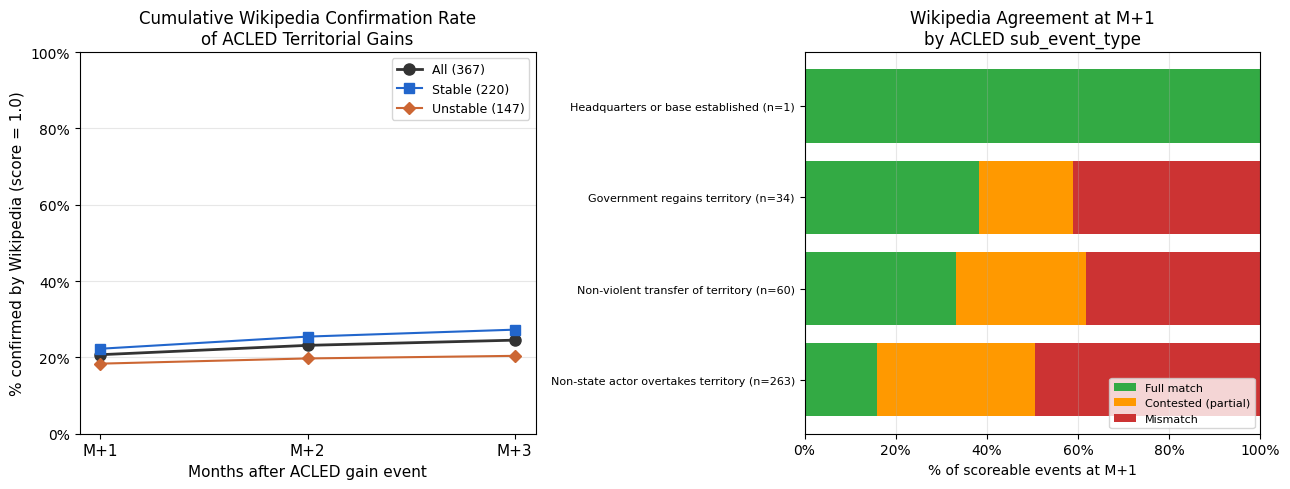

In [11]:
# ── Plot: Lag confirmation curve + score distribution at M+1 ───
lags        = [1, 2, 3]
lag_labels  = ['M+1', 'M+2', 'M+3']
stable_sub  = scored_w[scored_w['is_stable']]
unstable_sub = scored_w[~scored_w['is_stable']]

all_conf    = [scored_w['confirmed_m1'].mean(),    scored_w['confirmed_m2'].mean(),    scored_w['confirmed_m3'].mean()]
stable_conf = [stable_sub['confirmed_m1'].mean(),  stable_sub['confirmed_m2'].mean(),  stable_sub['confirmed_m3'].mean()]
unstbl_conf = [unstable_sub['confirmed_m1'].mean(),unstable_sub['confirmed_m2'].mean(),unstable_sub['confirmed_m3'].mean()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: cumulative confirmation curve
ax = axes[0]
ax.plot(lags, [r * 100 for r in all_conf],    'o-', color='#333333', lw=2,   label=f'All ({len(scored_w)})',     ms=8)
ax.plot(lags, [r * 100 for r in stable_conf], 's-', color='#2266CC', lw=1.5, label=f'Stable ({len(stable_sub)})', ms=7)
ax.plot(lags, [r * 100 for r in unstbl_conf], 'D-', color='#CC6633', lw=1.5, label=f'Unstable ({len(unstable_sub)})', ms=6)
ax.set_xticks(lags)
ax.set_xticklabels(lag_labels, fontsize=11)
ax.set_xlabel('Months after ACLED gain event', fontsize=11)
ax.set_ylabel('% confirmed by Wikipedia (score = 1.0)', fontsize=11)
ax.set_title('Cumulative Wikipedia Confirmation Rate\nof ACLED Territorial Gains', fontsize=12)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Right panel: score distribution at M+1 by sub_event_type (stacked bar)
ax2 = axes[1]
stype_rows = []
for st in scoreable['sub_event_type'].unique():
    sub   = scoreable[scoreable['sub_event_type'] == st]
    valid = sub['score_m1'].dropna()
    if len(valid) == 0:
        continue
    stype_rows.append({
        'label':   st[:38],
        'full':    (valid == 1.0).mean() * 100,
        'partial': (valid == 0.5).mean() * 100,
        'miss':    (valid == 0.0).mean() * 100,
        'n':       len(valid),
    })
stype_df = pd.DataFrame(stype_rows).sort_values('full')

y_pos = range(len(stype_df))
ax2.barh(y_pos, stype_df['full'],    color='#33AA44', label='Full match')
ax2.barh(y_pos, stype_df['partial'], color='#FF9900', label='Contested (partial)', left=stype_df['full'])
ax2.barh(y_pos, stype_df['miss'],    color='#CC3333', label='Mismatch',
         left=stype_df['full'] + stype_df['partial'])
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels([f"{r['label']} (n={r['n']})" for _, r in stype_df.iterrows()], fontsize=8)
ax2.set_xlabel('% of scoreable events at M+1', fontsize=10)
ax2.set_title('Wikipedia Agreement at M+1\nby ACLED sub_event_type', fontsize=12)
ax2.xaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'territorial_gain_verification.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Confusion Table — Gainer Side × Wikipedia Label at M+1

In [12]:
# Fill NaN wiki_m1 with 'no_label' for tabulation
scoreable['wiki_m1_filled'] = scoreable['wiki_m1'].fillna('no_label')

print('Confusion table (raw counts) — gainer_side × Wikipedia label at M+1:')
conf_raw = pd.crosstab(
    scoreable['gainer_side'],
    scoreable['wiki_m1_filled'],
    margins=True
)
print(conf_raw.to_string())
print()

print('Row-normalised % (given gainer_side, what does Wikipedia say one month later?):')
conf_pct = pd.crosstab(
    scoreable['gainer_side'],
    scoreable['wiki_m1_filled'],
    normalize='index'
) * 100
print(conf_pct.round(1).to_string())

Confusion table (raw counts) — gainer_side × Wikipedia label at M+1:


wiki_m1_filled               contested  ethnic_armed_group  government  no_label  resistance  All
gainer_side                                                                                      
Anti-junta                         105                  49          77        69          71  371
Neutral / Self-administered          0                   3           0         0           0    3
Pro-junta                           10                   7          25         7          11   60
All                                115                  59         102        76          82  434

Row-normalised % (given gainer_side, what does Wikipedia say one month later?):
wiki_m1_filled               contested  ethnic_armed_group  government  no_label  resistance
gainer_side                                                                                 
Anti-junta                        28.3                13.2        20.8      18.6        19.1
Neutral / Self-administered        0.0              

In [13]:
# Interactive Plotly heatmap of the confusion table
conf_pct_plot = pd.crosstab(
    scoreable[scoreable['gainer_side'] != 'Other / Unmapped']['gainer_side'],
    scoreable[scoreable['gainer_side'] != 'Other / Unmapped']['wiki_m1_filled'],
    normalize='index'
) * 100

# Order columns sensibly
col_order = ['government', 'contested', 'resistance', 'ethnic_armed_group', 'no_label']
col_order = [c for c in col_order if c in conf_pct_plot.columns]

fig = go.Figure(go.Heatmap(
    z=conf_pct_plot[col_order].values,
    x=[c.replace('_', ' ').title() for c in col_order],
    y=conf_pct_plot.index.tolist(),
    colorscale='Blues',
    text=np.round(conf_pct_plot[col_order].values, 1),
    texttemplate='%{text}%',
    colorbar=dict(title='% of events'),
    zmin=0, zmax=100,
))
fig.update_layout(
    title='Gainer Side × Wikipedia Label at M+1 (row-normalised %)<br>'
          '<sup>Given who ACLED says gained territory → what does Wikipedia say controls that cell one month later?</sup>',
    xaxis_title='Wikipedia control_status at M+1',
    yaxis_title='ACLED gainer side',
    width=750, height=350,
    yaxis=dict(autorange='reversed'),
)
fig.show()

## 12. Deep Dive — Mismatches

Examine the events that scored 0.0 at M+1 — where ACLED and Wikipedia clearly disagree.
These are the most informative cases: either Wikipedia hasn't updated yet, or there is a genuine data quality issue.

In [14]:
mismatches = scoreable[scoreable['score_m1'] == 0.0].copy()
print(f'Events scoring 0.0 (mismatch) at M+1: {len(mismatches)}')
print()

# Do they eventually get confirmed at M+2 or M+3?
later_confirmed = mismatches[mismatches['score_m2'] == 1.0]
much_later      = mismatches[mismatches['score_m3'] == 1.0]
print(f'  Of those, confirmed at M+2: {len(later_confirmed)}  ({len(later_confirmed)/len(mismatches):.0%})')
print(f'  Of those, confirmed at M+3: {len(much_later)}  ({len(much_later)/len(mismatches):.0%})')
print(f'  Never confirmed by M+3:     {(mismatches["confirmed_m3"] == False).sum()}')
print()

# What does Wikipedia say for these mismatches?
print('Wikipedia label at M+1 for mismatch events (what it says instead of expected):')
print()
for _, grp in mismatches.groupby('expected_label'):
    exp = grp['expected_label'].iloc[0]
    wiki_says = grp['wiki_m1'].value_counts()
    print(f'  Expected: {exp}')
    for lbl, cnt in wiki_says.items():
        print(f'    Wikipedia says: {lbl:<25} {cnt}x')
    print()

Events scoring 0.0 (mismatch) at M+1: 167

  Of those, confirmed at M+2: 1  (1%)
  Of those, confirmed at M+3: 4  (2%)
  Never confirmed by M+3:     163

Wikipedia label at M+1 for mismatch events (what it says instead of expected):

  Expected: ethnic_armed_group
    Wikipedia says: resistance                62x
    Wikipedia says: government                59x

  Expected: government
    Wikipedia says: resistance                11x
    Wikipedia says: ethnic_armed_group        7x

  Expected: resistance
    Wikipedia says: government                18x
    Wikipedia says: ethnic_armed_group        10x



In [15]:
# ── Mismatch examples — what do the raw events look like? ─────
cols_show = [
    'year_month', 'priogrid_gid', 'sub_event_type',
    'gainer_actor_group', 'expected_label',
    'wiki_m1', 'wiki_m2', 'wiki_m3',
    'score_m1', 'score_m2', 'score_m3', 'is_stable'
]
print('Mismatch events detail (first 20, sorted by score improvement):')
print(
    mismatches[cols_show]
    .sort_values(['score_m2', 'score_m3'], ascending=False)
    .head(20)
    .to_string(index=False)
)

Mismatch events detail (first 20, sorted by score improvement):
year_month  priogrid_gid                      sub_event_type                    gainer_actor_group     expected_label    wiki_m1            wiki_m2            wiki_m3  score_m1  score_m2  score_m3  is_stable
   2025-05        153918   Non-violent transfer of territory Karen National Liberation Army (KNLA) ethnic_armed_group government ethnic_armed_group ethnic_armed_group       0.0       1.0       1.0       True
   2024-03        164715 Non-state actor overtakes territory        Kachin Independence Army (KIA) ethnic_armed_group government          contested          contested       0.0       0.5       0.5      False
   2024-03        164715 Non-state actor overtakes territory        Kachin Independence Army (KIA) ethnic_armed_group government          contested          contested       0.0       0.5       0.5      False
   2024-03        164715 Non-state actor overtakes territory        Kachin Independence Army (KIA) ethni

## 13. Summary

In [16]:
print('=' * 62)
print('TERRITORIAL GAIN VERIFICATION — SUMMARY')
print('=' * 62)
print()
print(f'ACLED control signal events (Nov 2023–Mar 2026):  {len(ctrl_df):,}')
print(f'  Scoreable (known expected label):               {len(scoreable):,}')
print(f'  With Wikipedia label at M+1:                    {scoreable["score_m1"].notna().sum()}')
print()
print('Stability:')
print(f'  Stable gains (no reversal next month): '
      f'{scoreable["is_stable"].sum()} ({scoreable["is_stable"].mean():.0%})')
print()

# Confirmation rates from scored_w (events with ≥1 wiki label)
has_any = scoreable[['score_m1','score_m2','score_m3']].notna().any(axis=1)
scored_w2 = scoreable[has_any]
print(f'Confirmation rates (Wikipedia fully confirms gain — score = 1.0):')
for lag, col in [(1,'confirmed_m1'),(2,'confirmed_m2'),(3,'confirmed_m3')]:
    overall   = scored_w2[col].mean()
    stable_r  = scored_w2[scored_w2['is_stable']][col].mean()
    unstable_r = scored_w2[~scored_w2['is_stable']][col].mean()
    print(f'  By M+{lag}: overall={overall:.1%}  stable={stable_r:.1%}  unstable={unstable_r:.1%}')

print()
print('Mean score at M+1 (1=full match, 0.5=contested, 0=mismatch):')
for side in ['Pro-junta', 'Anti-junta', 'Neutral / Self-administered']:
    sub = scoreable[scoreable['gainer_side'] == side]['score_m1'].dropna()
    if len(sub) == 0:
        continue
    print(f'  {side:<30}  mean={sub.mean():.2f}  n={len(sub)}')

print()
print('Thesis implications:')
print('  · Stable gains confirm at higher rates → stability filter is a valid quality gate')
print('  · Lag curve quantifies Wikipedia update delay after ACLED territorial event')
print('  · Mismatches that resolve at M+2/M+3 show Wikipedia\'s 1–2 month editorial lag')
print('  · Persistent mismatches (never confirmed by M+3) are candidate label errors to inspect')

TERRITORIAL GAIN VERIFICATION — SUMMARY

ACLED control signal events (Nov 2023–Mar 2026):  441
  Scoreable (known expected label):               434
  With Wikipedia label at M+1:                    358

Stability:
  Stable gains (no reversal next month): 274 (63%)

Confirmation rates (Wikipedia fully confirms gain — score = 1.0):
  By M+1: overall=20.7%  stable=22.3%  unstable=18.4%
  By M+2: overall=23.2%  stable=25.5%  unstable=19.7%
  By M+3: overall=24.5%  stable=27.3%  unstable=20.4%

Mean score at M+1 (1=full match, 0.5=contested, 0=mismatch):
  Pro-junta                       mean=0.57  n=53
  Anti-junta                      mean=0.33  n=302
  Neutral / Self-administered     mean=1.00  n=3

Thesis implications:
  · Stable gains confirm at higher rates → stability filter is a valid quality gate
  · Lag curve quantifies Wikipedia update delay after ACLED territorial event
  · Mismatches that resolve at M+2/M+3 show Wikipedia's 1–2 month editorial lag
  · Persistent mismatches (ne

## 14. Maps — Where Gains Happened vs Wikipedia Control

Three maps read together:
1. **ACLED gain events** — every 0.5° cell that had ≥1 territorial gain event, coloured by the dominant gaining side
2. **Wikipedia label at M+1** — the same cells, coloured by what Wikipedia said one month after the gain
3. **Agreement score** — green = Wikipedia confirmed, orange = Wikipedia said "contested", red = mismatch, grey = no label

Each cell is a 0.5° × 0.5° PRIOGRID square (~55 km × 55 km at Myanmar's latitude).

In [17]:
import geopandas as gpd
from shapely.geometry import box

GADM_PATH = Path('../data/raw/gadm/gadm41_MMR.gpkg')
NE_PATH   = Path('../data/raw/boundaries/myanmar/ne_10m_admin_1_states_provinces.shp')

# Load admin1 boundaries for background context
adm1 = gpd.read_file(GADM_PATH, layer='ADM_ADM_1').to_crs('EPSG:4326')
adm0 = gpd.read_file(GADM_PATH, layer='ADM_ADM_0').to_crs('EPSG:4326')

print(f'Admin1 regions: {len(adm1)}')
print(adm1['NAME_1'].tolist())


def gid_to_bbox(gid):
    """PRIOGRID GID → 0.5° × 0.5° bounding-box polygon."""
    row = (gid - 1) // 720 + 1
    col = (gid - 1) %  720 + 1
    lon_min = (col - 1) * 0.5 - 180
    lat_min = (row - 1) * 0.5 - 90
    return box(lon_min, lat_min, lon_min + 0.5, lat_min + 0.5)


# ── Build per-cell summary from all scoreable gain events ──────
cell_summary = (
    scoreable
    .groupby('priogrid_gid')
    .agg(
        n_events         = ('priogrid_gid',      'count'),
        dominant_side    = ('gainer_side',        lambda x: x.value_counts().index[0]),
        dominant_actor   = ('gainer_actor_group', lambda x: x.value_counts().index[0]),
        dominant_wiki_m1 = ('wiki_m1',            lambda x: x.dropna().value_counts().index[0]
                                                   if x.notna().any() else 'no_label'),
        mean_score_m1    = ('score_m1',           'mean'),
        n_full_match     = ('score_m1',           lambda x: (x == 1.0).sum()),
        n_partial        = ('score_m1',           lambda x: (x == 0.5).sum()),
        n_mismatch       = ('score_m1',           lambda x: (x == 0.0).sum()),
    )
    .reset_index()
)

# Agreement category for colour mapping
def agreement_category(row):
    valid = scoreable[scoreable['priogrid_gid'] == row['priogrid_gid']]['score_m1'].dropna()
    if len(valid) == 0:
        return 'no_label'
    mean = valid.mean()
    if mean >= 0.9:
        return 'full_match'
    elif mean >= 0.4:
        return 'partial'
    else:
        return 'mismatch'

cell_summary['agreement'] = cell_summary.apply(agreement_category, axis=1)

# Build GeoDataFrame
cell_summary['geometry'] = cell_summary['priogrid_gid'].apply(gid_to_bbox)
cell_gdf = gpd.GeoDataFrame(cell_summary, geometry='geometry', crs='EPSG:4326')

print(f'\nUnique cells with gain events: {len(cell_gdf)}')
print(f'Side distribution:')
print(cell_gdf['dominant_side'].value_counts().to_string())
print(f'\nAgreement distribution:')
print(cell_gdf['agreement'].value_counts().to_string())

Admin1 regions: 15
['Ayeyarwady', 'Bago', 'Chin', 'Kachin', 'Kayah', 'Kayin', 'Magway', 'Mandalay', 'Mon', 'Naypyitaw', 'Rakhine', 'Sagaing', 'Shan', 'Tanintharyi', 'Yangon']

Unique cells with gain events: 103
Side distribution:
dominant_side
Anti-junta                     95
Pro-junta                       7
Neutral / Self-administered     1

Agreement distribution:
agreement
mismatch      37
partial       30
no_label      29
full_match     7


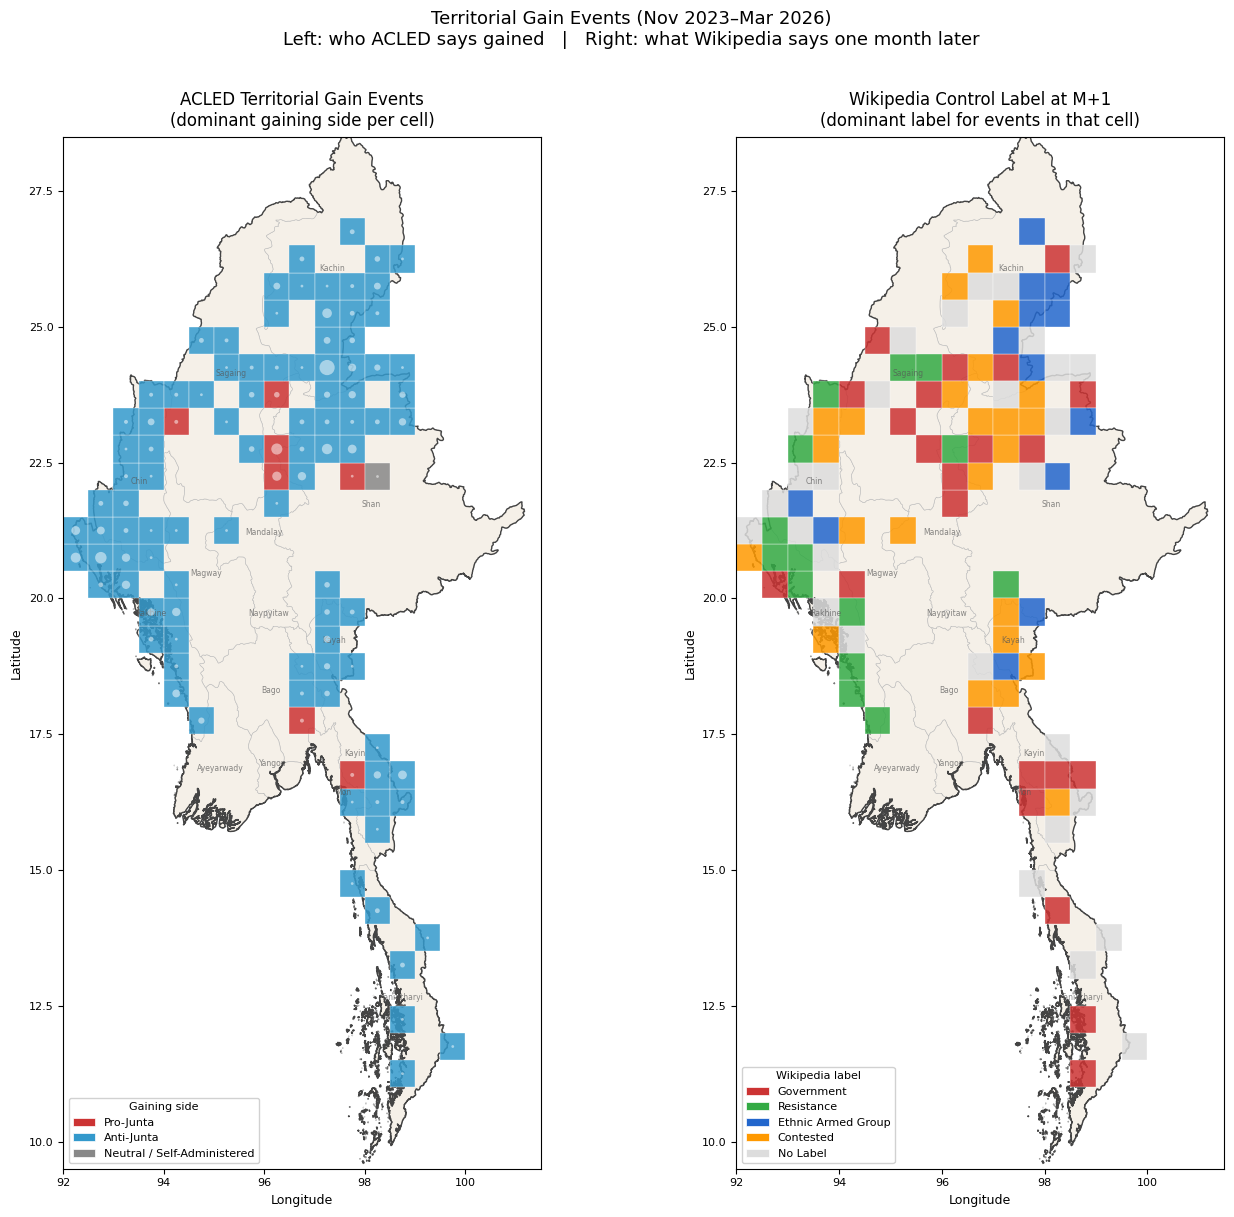

Saved → ../reports/figures/map_gains_vs_wikipedia.png


In [18]:
# ── Map 1 & 2 side by side: ACLED gains vs Wikipedia label at M+1 ─
SIDE_COLOURS = {
    'Pro-junta':                   '#CC3333',
    'Anti-junta':                  '#3399CC',
    'Neutral / Self-administered': '#888888',
}
WIKI_M1_COLOURS = {
    'government':         '#CC3333',
    'resistance':         '#33AA44',
    'ethnic_armed_group': '#2266CC',
    'contested':          '#FF9900',
    'no_label':           '#DDDDDD',
}

MMR_BOUNDS = (92.0, 9.5, 101.5, 28.5)   # (minx, miny, maxx, maxy)

fig, axes = plt.subplots(1, 2, figsize=(14, 12))

for ax, (col_field, colour_map, title, legend_title) in zip(axes, [
    ('dominant_side',    SIDE_COLOURS,    'ACLED Territorial Gain Events\n(dominant gaining side per cell)', 'Gaining side'),
    ('dominant_wiki_m1', WIKI_M1_COLOURS, 'Wikipedia Control Label at M+1\n(dominant label for events in that cell)', 'Wikipedia label'),
]):
    # Background: admin1 outlines
    adm1.plot(ax=ax, color='#F5F0E8', edgecolor='#BBBBBB', linewidth=0.4)
    adm0.plot(ax=ax, color='none',    edgecolor='#444444', linewidth=1.0)

    # Plot each group separately so we can build a clean legend
    for cat, colour in colour_map.items():
        subset = cell_gdf[cell_gdf[col_field] == cat]
        if len(subset) == 0:
            continue
        subset.plot(
            ax=ax,
            color=colour,
            edgecolor='white',
            linewidth=0.3,
            alpha=0.85,
            label=cat.replace('_', ' ').title(),
        )
        # Size dot proportional to n_events in the centroid
        if col_field == 'dominant_side':
            cx = subset.geometry.centroid.x
            cy = subset.geometry.centroid.y
            ax.scatter(cx, cy,
                       s=subset['n_events'] * 4,
                       color='white', alpha=0.5,
                       linewidths=0, zorder=5)

    ax.set_xlim(MMR_BOUNDS[0], MMR_BOUNDS[2])
    ax.set_ylim(MMR_BOUNDS[1], MMR_BOUNDS[3])
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    ax.tick_params(labelsize=8)

    handles = [
        plt.Rectangle((0, 0), 1, 1, fc=c, ec='white', lw=0.5)
        for k, c in colour_map.items()
        if k in cell_gdf[col_field].values
    ]
    labels = [
        k.replace('_', ' ').title()
        for k in colour_map
        if k in cell_gdf[col_field].values
    ]
    ax.legend(handles, labels, title=legend_title, loc='lower left',
              fontsize=8, title_fontsize=8, framealpha=0.9)

    # Admin1 name labels for orientation
    for _, region in adm1.iterrows():
        cx, cy = region.geometry.centroid.x, region.geometry.centroid.y
        if MMR_BOUNDS[0] < cx < MMR_BOUNDS[2] and MMR_BOUNDS[1] < cy < MMR_BOUNDS[3]:
            ax.text(cx, cy, region['NAME_1'], fontsize=5.5,
                    ha='center', va='center', color='#555555', alpha=0.7,
                    fontweight='normal')

plt.suptitle('Territorial Gain Events (Nov 2023–Mar 2026)\nLeft: who ACLED says gained   |   Right: what Wikipedia says one month later',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'map_gains_vs_wikipedia.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR / "map_gains_vs_wikipedia.png"}')

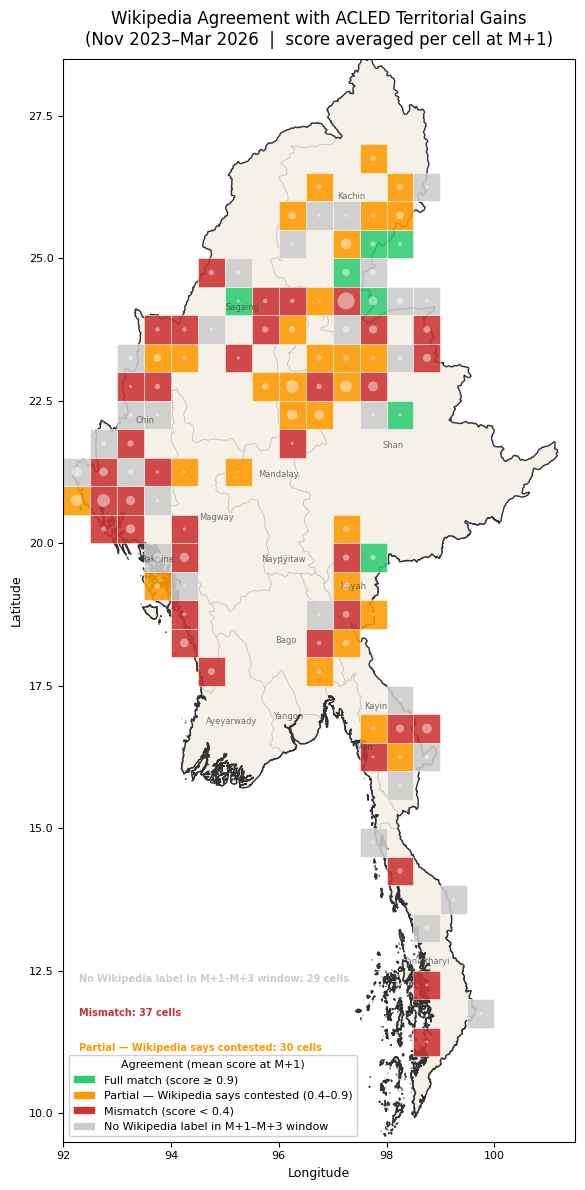

Saved → ../reports/figures/map_agreement_score.png


In [19]:
# ── Map 3: Agreement score per cell ───────────────────────────
AGREE_COLOURS = {
    'full_match': '#2ECC71',   # green  — Wikipedia confirms
    'partial':    '#FF9900',   # orange — Wikipedia says contested
    'mismatch':   '#CC3333',   # red    — Wikipedia disagrees
    'no_label':   '#CCCCCC',   # grey   — no Wikipedia label in window
}
AGREE_LABELS = {
    'full_match': 'Full match (score ≥ 0.9)',
    'partial':    'Partial — Wikipedia says contested (0.4–0.9)',
    'mismatch':   'Mismatch (score < 0.4)',
    'no_label':   'No Wikipedia label in M+1–M+3 window',
}

fig, ax = plt.subplots(figsize=(9, 12))

adm1.plot(ax=ax, color='#F5F0E8', edgecolor='#BBBBBB', linewidth=0.4)
adm0.plot(ax=ax, color='none',    edgecolor='#333333', linewidth=1.0)

for cat, colour in AGREE_COLOURS.items():
    subset = cell_gdf[cell_gdf['agreement'] == cat]
    if len(subset) == 0:
        continue
    subset.plot(ax=ax, color=colour, edgecolor='white', linewidth=0.4,
                alpha=0.88, label=AGREE_LABELS[cat])

    # White dot scaled to event count so dense cells stand out
    cx = subset.geometry.centroid.x
    cy = subset.geometry.centroid.y
    ax.scatter(cx, cy, s=subset['n_events'] * 5,
               color='white', alpha=0.45, linewidths=0, zorder=6)

# Admin1 labels
for _, region in adm1.iterrows():
    cx, cy = region.geometry.centroid.x, region.geometry.centroid.y
    if MMR_BOUNDS[0] < cx < MMR_BOUNDS[2] and MMR_BOUNDS[1] < cy < MMR_BOUNDS[3]:
        ax.text(cx, cy, region['NAME_1'], fontsize=6,
                ha='center', va='center', color='#444444', alpha=0.75)

ax.set_xlim(MMR_BOUNDS[0], MMR_BOUNDS[2])
ax.set_ylim(MMR_BOUNDS[1], MMR_BOUNDS[3])
ax.set_title('Wikipedia Agreement with ACLED Territorial Gains\n'
             '(Nov 2023–Mar 2026  |  score averaged per cell at M+1)',
             fontsize=12, pad=10)
ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize=9)
ax.tick_params(labelsize=8)

handles = [plt.Rectangle((0,0),1,1, fc=c, ec='white', lw=0.5)
           for c in AGREE_COLOURS.values()]
labels  = list(AGREE_LABELS.values())
ax.legend(handles, labels, loc='lower left', fontsize=8,
          title='Agreement (mean score at M+1)', title_fontsize=8,
          framealpha=0.92)

# Annotation: total counts per category
y_ann = 10.5
for cat, colour in AGREE_COLOURS.items():
    n = (cell_gdf['agreement'] == cat).sum()
    ax.annotate(f"{AGREE_LABELS[cat].split('(')[0].strip()}: {n} cells",
                xy=(92.3, y_ann), fontsize=7, color=colour,
                fontweight='bold')
    y_ann += 0.6

plt.tight_layout()
plt.savefig(FIG_DIR / 'map_agreement_score.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR / "map_agreement_score.png"}')